In [1]:

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:

print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.6.0+cpu
TorchVision: 0.21.0+cpu
CUDA available: False


## loading data 

In [3]:

BASE_DIR = os.path.abspath("..")

SKIN_DIR = os.path.join(
    BASE_DIR,
    "data",
    "skin"
)

IMAGE_DIR = os.path.join(
    SKIN_DIR,
    "ISBI2016_ISIC_Part3_Training_Data"
)

CSV_PATH = os.path.join(
    SKIN_DIR,
    "ISBI2016_ISIC_Part3_Training_GroundTruth.csv"
)

print("Skin directory:")
print(SKIN_DIR)

print("\nImage directory:")
print(IMAGE_DIR)

print("\nCSV path:")
print(CSV_PATH)

print("\nImage folder exists:", os.path.exists(IMAGE_DIR))
print("CSV exists:", os.path.exists(CSV_PATH))

Skin directory:
C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\data\skin

Image directory:
C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\data\skin\ISBI2016_ISIC_Part3_Training_Data

CSV path:
C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\data\skin\ISBI2016_ISIC_Part3_Training_GroundTruth.csv

Image folder exists: True
CSV exists: True


In [4]:

df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (899, 2)

Columns:
['ISIC_0000000', 'benign']

First 5 rows:


,ISIC_0000000,benign
0,ISIC_0000001,benign
1,ISIC_0000002,malignant
2,ISIC_0000004,malignant
3,ISIC_0000006,benign
4,ISIC_0000007,benign


In [5]:

# Rename columns
df.columns = ["image_id", "label"]

# Add .jpg extension
df["image_path"] = df["image_id"].apply(
    lambda x: os.path.join(IMAGE_DIR, x + ".jpg")
)

# Check whether images exist
df["exists"] = df["image_path"].apply(os.path.exists)

print("Total labeled images:", len(df))
print("Images found:", df["exists"].sum())
print("Images missing:", (~df["exists"]).sum())

# Keep only images that actually exist
df = df[df["exists"]].copy()

# Convert labels to numbers
df["target"] = df["label"].map({
    "benign": 0,
    "malignant": 1
})

print("\nFinal dataset shape:", df.shape)

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nFirst 5 rows:")
display(df.head())

Total labeled images: 899
Images found: 899
Images missing: 0

Final dataset shape: (899, 5)

Class distribution:
label
benign       726
malignant    173
Name: count, dtype: int64

First 5 rows:


,image_id,label,image_path,exists,target
0,ISIC_0000001,benign,C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\...,True,0
1,ISIC_0000002,malignant,C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\...,True,1
2,ISIC_0000004,malignant,C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\...,True,1
3,ISIC_0000006,benign,C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\...,True,0
4,ISIC_0000007,benign,C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\...,True,0


## Visualize Sample Skin Lesion Images

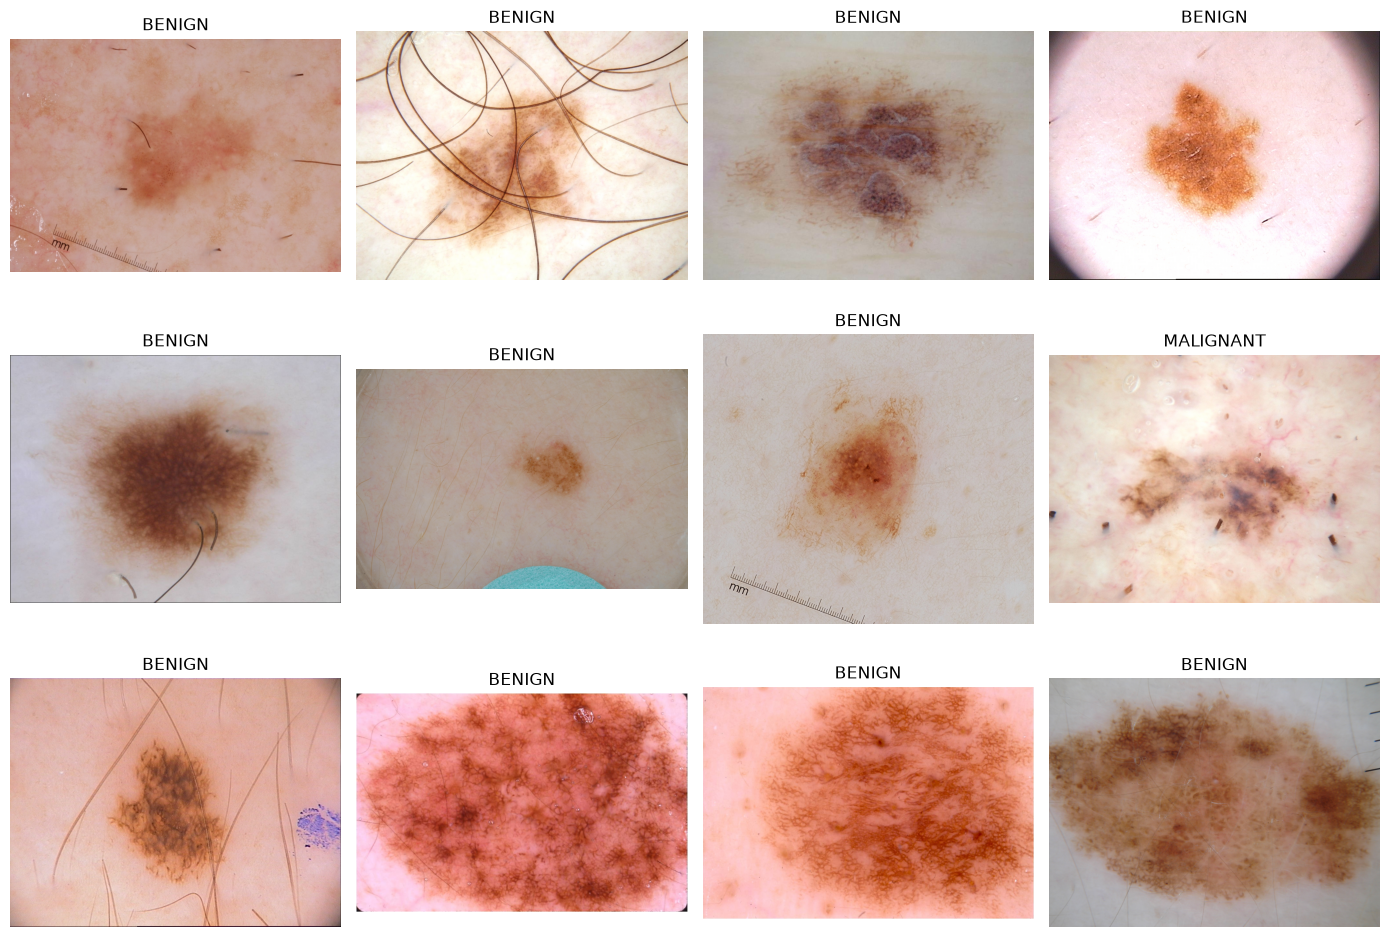

In [6]:
import random

plt.figure(figsize=(14, 10))

sample_df = df.sample(
    min(12, len(df)),
    random_state=42
)

for i, (_, row) in enumerate(sample_df.iterrows()):

    image = Image.open(row["image_path"]).convert("RGB")

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(row["label"].upper())
    plt.axis("off")

plt.tight_layout()
plt.show()

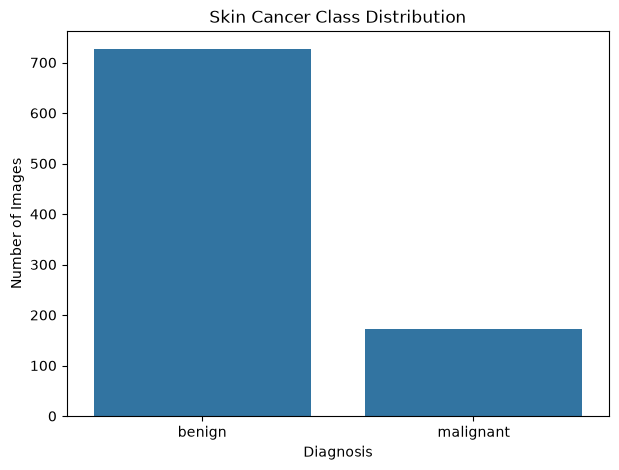

In [8]:

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Skin Cancer Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Images")

plt.show()


## Train/Validation split

In [9]:
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["target"],
    random_state=42
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

Training samples: 719
Validation samples: 180

Training distribution:
label
benign       581
malignant    138
Name: count, dtype: int64

Validation distribution:
label
benign       145
malignant     35
Name: count, dtype: int64


In [10]:

IMG_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image transformations ready.")

Image transformations ready.


## Custom Skin Cancer Dataset

In [11]:


class SkinCancerDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["image_path"]
        label = int(row["target"])

        # Load image
        image = Image.open(image_path).convert("RGB")

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        return image, label


# Create datasets
train_dataset = SkinCancerDataset(
    train_df,
    transform=train_transforms
)

val_dataset = SkinCancerDataset(
    val_df,
    transform=val_transforms
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Training dataset: 719
Validation dataset: 180


In [12]:

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 45
Validation batches: 12


In [13]:

#  Test DataLoader


images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

Image batch shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [14]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# Count training classes
class_counts = train_df["target"].value_counts().sort_index()

print("\nClass counts:")
print(class_counts)

# Calculate class weights
total = len(train_df)

class_weights = torch.tensor(
    [
        total / (2 * class_counts[0]),
        total / (2 * class_counts[1])
    ],
    dtype=torch.float32
).to(device)

print("\nClass weights:")
print(class_weights)

Using device: cpu

Class counts:
target
0    581
1    138
Name: count, dtype: int64

Class weights:
tensor([0.6188, 2.6051])


## Load ResNet18

In [15]:

weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)

# Number of input features to the final layer
num_features = model.fc.in_features

# Replace final classifier
model.fc = nn.Linear(
    num_features,
    2
)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


## Freeze ResNet Backbone

In [16]:

for param in model.parameters():
    param.requires_grad = False

# Train only final classifier
for param in model.fc.parameters():
    param.requires_grad = True

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Trainable parameters:", trainable_params)
print("Total parameters:", total_params)

Trainable parameters: 1026
Total parameters: 11177538


In [17]:

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [18]:
 # Training Function
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)
        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [19]:
# ============================================================
# Create model output directory
# ============================================================

MODEL_DIR = os.path.join(
    BASE_DIR,
    "models",
    "skin"
)

os.makedirs(MODEL_DIR, exist_ok=True)

print("Model directory:", MODEL_DIR)
print("Directory exists:", os.path.exists(MODEL_DIR))

Model directory: C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\models\skin
Directory exists: True


In [20]:
#: Validation Function

def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            probabilities = torch.softmax(
                outputs,
                dim=1
            )[:, 1]

            _, predicted = torch.max(
                outputs,
                1
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predicted.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return (
        epoch_loss,
        epoch_accuracy,
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )

In [21]:

# Train ResNet18


EPOCHS = 10

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    (
        val_loss,
        val_acc,
        y_true,
        y_pred,
        y_prob
    ) = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "../models/skin/best_resnet18.pth"
        )

        print("  → Best model saved!")

Epoch [1/10] Train Loss: 0.7040 Train Acc: 0.5925 Val Loss: 0.6474 Val Acc: 0.7167
  → Best model saved!
Epoch [2/10] Train Loss: 0.6285 Train Acc: 0.6384 Val Loss: 0.6243 Val Acc: 0.7889
  → Best model saved!
Epoch [3/10] Train Loss: 0.5946 Train Acc: 0.7107 Val Loss: 0.6066 Val Acc: 0.7833
  → Best model saved!
Epoch [4/10] Train Loss: 0.5815 Train Acc: 0.7232 Val Loss: 0.6209 Val Acc: 0.7778
Epoch [5/10] Train Loss: 0.5772 Train Acc: 0.7191 Val Loss: 0.5753 Val Acc: 0.7389
  → Best model saved!
Epoch [6/10] Train Loss: 0.5617 Train Acc: 0.7121 Val Loss: 0.5968 Val Acc: 0.5333
Epoch [7/10] Train Loss: 0.5571 Train Acc: 0.7469 Val Loss: 0.5549 Val Acc: 0.7333
  → Best model saved!
Epoch [8/10] Train Loss: 0.5494 Train Acc: 0.7316 Val Loss: 0.6891 Val Acc: 0.7889
Epoch [9/10] Train Loss: 0.5525 Train Acc: 0.7316 Val Loss: 0.5819 Val Acc: 0.6000
Epoch [10/10] Train Loss: 0.5660 Train Acc: 0.7357 Val Loss: 0.5649 Val Acc: 0.7611


In [22]:
# ============================================================
# Cell 19: Load Best ResNet18 Model
# ============================================================

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_resnet18.pth"
)

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)

print("Best ResNet18 model loaded successfully!")
print("Model path:", BEST_MODEL_PATH)

Best ResNet18 model loaded successfully!
Model path: C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\models\skin\best_resnet18.pth


In [23]:
# ============================================================
# Cell 20: Model Evaluation
# ============================================================

(
    val_loss,
    val_accuracy,
    y_true,
    y_pred,
    y_prob
) = validate(
    model,
    val_loader,
    criterion,
    device
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_true,
    y_prob
)

print("========================================")
print("      RESNET18 EVALUATION")
print("========================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

      RESNET18 EVALUATION
Accuracy : 0.7333
Precision: 0.4000
Recall   : 0.7429
F1 Score : 0.5200
ROC-AUC  : 0.7785


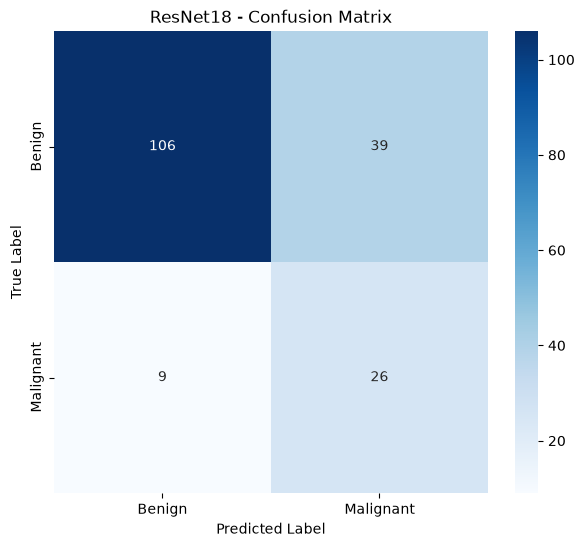


Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.73      0.82       145
   Malignant       0.40      0.74      0.52        35

    accuracy                           0.73       180
   macro avg       0.66      0.74      0.67       180
weighted avg       0.82      0.73      0.76       180



In [24]:
# ============================================================
# Cell 21: Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("ResNet18 - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Benign", "Malignant"],
        zero_division=0
    )
)


In [25]:
# ============================================================
# Cell 22: Fine-Tune ResNet18
# ============================================================

# Unfreeze Layer 4
for param in model.layer4.parameters():
    param.requires_grad = True

# Keep classifier trainable
for param in model.fc.parameters():
    param.requires_grad = True

# Count parameters
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", trainable_params)

# Lower learning rate for fine-tuning
optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=0.0001,
    weight_decay=1e-4
)

print("\nFine-tuning optimizer:")
print(optimizer)

Trainable parameters: 8394754

Fine-tuning optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [26]:
# ============================================================
# Cell 23: Fine-Tuning Training
# ============================================================

FINE_TUNE_EPOCHS = 10

fine_train_losses = []
fine_val_losses = []

fine_train_accs = []
fine_val_accs = []

best_fine_val_loss = float("inf")

for epoch in range(FINE_TUNE_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    (
        val_loss,
        val_acc,
        y_true_temp,
        y_pred_temp,
        y_prob_temp
    ) = validate(
        model,
        val_loader,
        criterion,
        device
    )

    fine_train_losses.append(train_loss)
    fine_val_losses.append(val_loss)

    fine_train_accs.append(train_acc)
    fine_val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{FINE_TUNE_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_fine_val_loss:

        best_fine_val_loss = val_loss

        torch.save(
            model.state_dict(),
            os.path.join(
                MODEL_DIR,
                "best_resnet18_finetuned.pth"
            )
        )

        print("  → Best fine-tuned model saved!")

Epoch [1/10] Train Loss: 0.6083 Train Acc: 0.6829 Val Loss: 0.6235 Val Acc: 0.7111
  → Best fine-tuned model saved!
Epoch [2/10] Train Loss: 0.4828 Train Acc: 0.7580 Val Loss: 0.7088 Val Acc: 0.7000
Epoch [3/10] Train Loss: 0.4471 Train Acc: 0.7830 Val Loss: 0.5423 Val Acc: 0.7556
  → Best fine-tuned model saved!
Epoch [4/10] Train Loss: 0.4247 Train Acc: 0.8108 Val Loss: 0.5976 Val Acc: 0.7944
Epoch [5/10] Train Loss: 0.3879 Train Acc: 0.8567 Val Loss: 0.6203 Val Acc: 0.7278
Epoch [6/10] Train Loss: 0.3329 Train Acc: 0.8581 Val Loss: 0.6177 Val Acc: 0.7389
Epoch [7/10] Train Loss: 0.3071 Train Acc: 0.8776 Val Loss: 0.8468 Val Acc: 0.7889
Epoch [8/10] Train Loss: 0.2928 Train Acc: 0.8846 Val Loss: 0.6872 Val Acc: 0.6889
Epoch [9/10] Train Loss: 0.2592 Train Acc: 0.8887 Val Loss: 0.6671 Val Acc: 0.6944
Epoch [10/10] Train Loss: 0.2401 Train Acc: 0.9040 Val Loss: 0.8871 Val Acc: 0.7944


In [27]:
# ============================================================
# Cell 24: Load Best Fine-Tuned Model
# ============================================================

BEST_FINETUNED_PATH = os.path.join(
    MODEL_DIR,
    "best_resnet18_finetuned.pth"
)

model.load_state_dict(
    torch.load(
        BEST_FINETUNED_PATH,
        map_location=device
    )
)

model = model.to(device)

print("Best fine-tuned ResNet18 loaded!")
print("Path:", BEST_FINETUNED_PATH)

Best fine-tuned ResNet18 loaded!
Path: C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\models\skin\best_resnet18_finetuned.pth


In [28]:
# ============================================================
# Cell 25: Fine-Tuned Model Evaluation
# ============================================================

(
    val_loss,
    val_accuracy,
    y_true,
    y_pred,
    y_prob
) = validate(
    model,
    val_loader,
    criterion,
    device
)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_true,
    y_prob
)

print("========================================")
print(" FINE-TUNED RESNET18 EVALUATION")
print("========================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

 FINE-TUNED RESNET18 EVALUATION
Accuracy : 0.7556
Precision: 0.4211
Recall   : 0.6857
F1 Score : 0.5217
ROC-AUC  : 0.8142


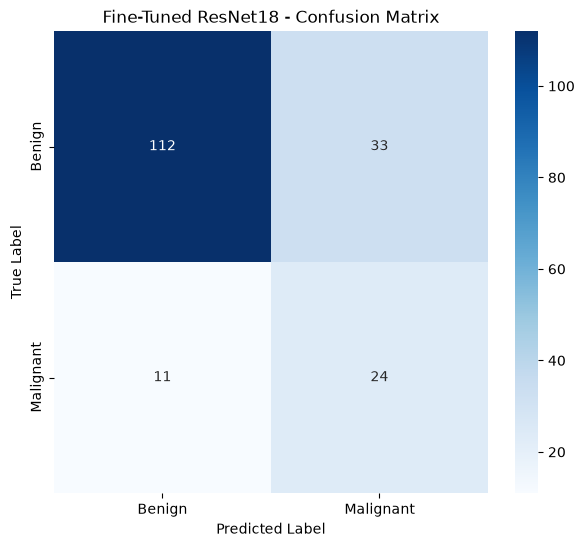


Classification Report:
              precision    recall  f1-score   support

      Benign       0.91      0.77      0.84       145
   Malignant       0.42      0.69      0.52        35

    accuracy                           0.76       180
   macro avg       0.67      0.73      0.68       180
weighted avg       0.82      0.76      0.77       180



In [29]:
# ============================================================
# Cell 26: Fine-Tuned Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Fine-Tuned ResNet18 - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Benign", "Malignant"],
        zero_division=0
    )
)

In [31]:
# ============================================================
# Cell 27: Balanced Training Sampler
# ============================================================

from torch.utils.data import WeightedRandomSampler

# Count classes
class_counts = train_df["target"].value_counts().sort_index()

print("Class counts:")
print(class_counts)

# Class weights
class_weights_sampler = {
    0: 1.0 / class_counts[0],
    1: 1.0 / class_counts[1]
}

# Calculate sample weights
sample_weights = train_df["target"].map(
    class_weights_sampler
).to_numpy(copy=True)

# Convert to writable PyTorch tensor
sample_weights = torch.tensor(
    sample_weights,
    dtype=torch.double
)

# Create balanced sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Balanced DataLoader
balanced_train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler,
    num_workers=0
)

print("\nBalanced DataLoader created!")
print("Samples per epoch:", len(balanced_train_loader.dataset))

Class counts:
target
0    581
1    138
Name: count, dtype: int64

Balanced DataLoader created!
Samples per epoch: 719


In [32]:
# ============================================================
# Cell 28: Improved ResNet18 Model
# ============================================================

weights = models.ResNet18_Weights.DEFAULT

model_v2 = models.resnet18(weights=weights)

# Replace classifier
num_features = model_v2.fc.in_features

model_v2.fc = nn.Linear(
    num_features,
    2
)

model_v2 = model_v2.to(device)

print("Improved ResNet18 created!")
print("Device:", device)
print("Output classes:", 2)

Improved ResNet18 created!
Device: cpu
Output classes: 2


In [33]:
# ============================================================
# Cell 29: Freeze Backbone
# ============================================================

for param in model_v2.parameters():
    param.requires_grad = False

for param in model_v2.fc.parameters():
    param.requires_grad = True

trainable_params = sum(
    p.numel()
    for p in model_v2.parameters()
    if p.requires_grad
)

print("Trainable parameters:", trainable_params)

Trainable parameters: 1026


In [34]:
# ============================================================
# Cell 30: Loss + Optimizer
# ============================================================

# Balanced sampler already handles class imbalance
criterion_v2 = nn.CrossEntropyLoss()

optimizer_v2 = optim.Adam(
    model_v2.fc.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print("Loss:", criterion_v2)
print("Learning rate: 0.001")
print("Weight decay: 0.0001")

Loss: CrossEntropyLoss()
Learning rate: 0.001
Weight decay: 0.0001


In [35]:
# ============================================================
# Cell 31: Train Improved CNN v2
# ============================================================

EPOCHS_V2 = 8

v2_train_losses = []
v2_val_losses = []

v2_train_accs = []
v2_val_accs = []

best_v2_val_loss = float("inf")

V2_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_resnet18_v2.pth"
)

for epoch in range(EPOCHS_V2):

    train_loss, train_acc = train_one_epoch(
        model_v2,
        balanced_train_loader,
        criterion_v2,
        optimizer_v2,
        device
    )

    (
        val_loss,
        val_acc,
        y_true_v2,
        y_pred_v2,
        y_prob_v2
    ) = validate(
        model_v2,
        val_loader,
        criterion_v2,
        device
    )

    v2_train_losses.append(train_loss)
    v2_val_losses.append(val_loss)

    v2_train_accs.append(train_acc)
    v2_val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS_V2}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_v2_val_loss:

        best_v2_val_loss = val_loss

        torch.save(
            model_v2.state_dict(),
            V2_MODEL_PATH
        )

        print("  → Best V2 model saved!")

Epoch [1/8] Train Loss: 0.6489 Train Acc: 0.6175 Val Loss: 0.6459 Val Acc: 0.6611
  → Best V2 model saved!
Epoch [2/8] Train Loss: 0.6218 Train Acc: 0.6412 Val Loss: 0.4814 Val Acc: 0.7389
  → Best V2 model saved!
Epoch [3/8] Train Loss: 0.5856 Train Acc: 0.6787 Val Loss: 0.4936 Val Acc: 0.7333
Epoch [4/8] Train Loss: 0.5880 Train Acc: 0.6745 Val Loss: 0.5244 Val Acc: 0.7222
Epoch [5/8] Train Loss: 0.5465 Train Acc: 0.7038 Val Loss: 0.5544 Val Acc: 0.7000
Epoch [6/8] Train Loss: 0.5922 Train Acc: 0.6759 Val Loss: 0.7911 Val Acc: 0.5833
Epoch [7/8] Train Loss: 0.5744 Train Acc: 0.6898 Val Loss: 0.7668 Val Acc: 0.5667
Epoch [8/8] Train Loss: 0.5280 Train Acc: 0.7413 Val Loss: 0.7015 Val Acc: 0.5833


In [36]:
# ============================================================
# Cell 32: Evaluate Improved ResNet18 V2
# ============================================================

# Load best V2 checkpoint
model_v2.load_state_dict(
    torch.load(
        V2_MODEL_PATH,
        map_location=device
    )
)

model_v2 = model_v2.to(device)

print("Best V2 model loaded!")

# Evaluate
(
    val_loss_v2,
    val_accuracy_v2,
    y_true_v2,
    y_pred_v2,
    y_prob_v2
) = validate(
    model_v2,
    val_loader,
    criterion_v2,
    device
)

accuracy_v2 = accuracy_score(
    y_true_v2,
    y_pred_v2
)

precision_v2 = precision_score(
    y_true_v2,
    y_pred_v2,
    zero_division=0
)

recall_v2 = recall_score(
    y_true_v2,
    y_pred_v2,
    zero_division=0
)

f1_v2 = f1_score(
    y_true_v2,
    y_pred_v2,
    zero_division=0
)

roc_auc_v2 = roc_auc_score(
    y_true_v2,
    y_prob_v2
)

print("\n========================================")
print("     IMPROVED RESNET18 V2")
print("========================================")

print(f"Accuracy : {accuracy_v2:.4f}")
print(f"Precision: {precision_v2:.4f}")
print(f"Recall   : {recall_v2:.4f}")
print(f"F1 Score : {f1_v2:.4f}")
print(f"ROC-AUC  : {roc_auc_v2:.4f}")

Best V2 model loaded!

     IMPROVED RESNET18 V2
Accuracy : 0.7389
Precision: 0.3421
Recall   : 0.3714
F1 Score : 0.3562
ROC-AUC  : 0.7608


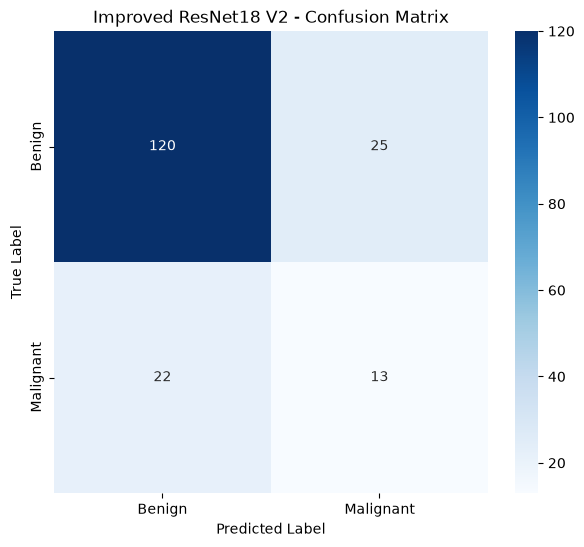


Classification Report:
              precision    recall  f1-score   support

      Benign       0.85      0.83      0.84       145
   Malignant       0.34      0.37      0.36        35

    accuracy                           0.74       180
   macro avg       0.59      0.60      0.60       180
weighted avg       0.75      0.74      0.74       180



In [37]:
# ============================================================
# Cell 33: V2 Confusion Matrix
# ============================================================

cm_v2 = confusion_matrix(
    y_true_v2,
    y_pred_v2
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_v2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Improved ResNet18 V2 - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

print("\nClassification Report:")
print(
    classification_report(
        y_true_v2,
        y_pred_v2,
        target_names=["Benign", "Malignant"],
        zero_division=0
    )
)

In [38]:
# ============================================================
# Cell 34: CNN V3 Image Transformations
# ============================================================

IMG_SIZE = 224

train_transforms_v3 = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_transforms_v3 = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("V3 transformations ready!")

V3 transformations ready!


In [39]:
# ============================================================
# Cell 35: V3 Datasets and DataLoaders
# ============================================================

train_dataset_v3 = SkinCancerDataset(
    train_df,
    transform=train_transforms_v3
)

val_dataset_v3 = SkinCancerDataset(
    val_df,
    transform=val_transforms_v3
)

train_loader_v3 = DataLoader(
    train_dataset_v3,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

val_loader_v3 = DataLoader(
    val_dataset_v3,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print("V3 Training images:", len(train_dataset_v3))
print("V3 Validation images:", len(val_dataset_v3))

V3 Training images: 719
V3 Validation images: 180


In [40]:
# ============================================================
# Cell 36: ResNet18 V3
# ============================================================

weights = models.ResNet18_Weights.DEFAULT

model_v3 = models.resnet18(
    weights=weights
)

# Replace classifier
num_features = model_v3.fc.in_features

model_v3.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, 2)
)

model_v3 = model_v3.to(device)

print("ResNet18 V3 created!")

ResNet18 V3 created!


In [41]:
# ============================================================
# Cell 37: V3 Trainable Layers
# ============================================================

# Freeze everything
for param in model_v3.parameters():
    param.requires_grad = False

# Unfreeze Layer 4
for param in model_v3.layer4.parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model_v3.fc.parameters():
    param.requires_grad = True

trainable_params_v3 = sum(
    p.numel()
    for p in model_v3.parameters()
    if p.requires_grad
)

print("V3 trainable parameters:", trainable_params_v3)

V3 trainable parameters: 8394754


In [42]:
# ============================================================
# Cell 38: V3 Loss, Optimizer and Scheduler
# ============================================================

class_weights_v3 = torch.tensor(
    [0.8, 1.8],
    dtype=torch.float32
).to(device)

criterion_v3 = nn.CrossEntropyLoss(
    weight=class_weights_v3
)

optimizer_v3 = optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model_v3.parameters()
    ),
    lr=0.0001,
    weight_decay=1e-4
)

scheduler_v3 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v3,
    mode="min",
    factor=0.5,
    patience=2
)

print("V3 optimizer:", optimizer_v3)
print("V3 scheduler:", scheduler_v3)
print("V3 class weights:", class_weights_v3)

V3 optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)
V3 scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x00000269C0C47DA0>
V3 class weights: tensor([0.8000, 1.8000])


In [43]:
# ============================================================
# Cell 39: Train CNN V3
# ============================================================

EPOCHS_V3 = 15
PATIENCE = 4

best_v3_val_loss = float("inf")
patience_counter = 0

v3_history = []

V3_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_resnet18_v3.pth"
)

for epoch in range(EPOCHS_V3):

    train_loss, train_acc = train_one_epoch(
        model_v3,
        train_loader_v3,
        criterion_v3,
        optimizer_v3,
        device
    )

    (
        val_loss,
        val_acc,
        y_true_v3_temp,
        y_pred_v3_temp,
        y_prob_v3_temp
    ) = validate(
        model_v3,
        val_loader_v3,
        criterion_v3,
        device
    )

    # Scheduler
    scheduler_v3.step(val_loss)

    v3_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    print(
        f"Epoch [{epoch+1}/{EPOCHS_V3}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

    # Save best model
    if val_loss < best_v3_val_loss:

        best_v3_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model_v3.state_dict(),
            V3_MODEL_PATH
        )

        print("  → Best V3 model saved!")

    else:

        patience_counter += 1

        print(
            f"  → No improvement "
            f"({patience_counter}/{PATIENCE})"
        )

    # Early stopping
    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")

        break

print("\nV3 training completed!")

Epoch [1/15] Train Loss: 0.6209 Train Acc: 0.6871 Val Loss: 0.5021 Val Acc: 0.7667
  → Best V3 model saved!
Epoch [2/15] Train Loss: 0.5142 Train Acc: 0.7886 Val Loss: 0.6069 Val Acc: 0.7611
  → No improvement (1/4)
Epoch [3/15] Train Loss: 0.4187 Train Acc: 0.8164 Val Loss: 0.5429 Val Acc: 0.7333
  → No improvement (2/4)
Epoch [4/15] Train Loss: 0.4217 Train Acc: 0.8289 Val Loss: 0.5378 Val Acc: 0.7611
  → No improvement (3/4)
Epoch [5/15] Train Loss: 0.3299 Train Acc: 0.8873 Val Loss: 0.5750 Val Acc: 0.8278
  → No improvement (4/4)

Early stopping triggered.

V3 training completed!


In [44]:
# ============================================================
# Cell 40: Evaluate Best-Loss V3 Model
# ============================================================

model_v3.load_state_dict(
    torch.load(
        V3_MODEL_PATH,
        map_location=device
    )
)

model_v3 = model_v3.to(device)

(
    val_loss_v3,
    val_accuracy_v3,
    y_true_v3,
    y_pred_v3,
    y_prob_v3
) = validate(
    model_v3,
    val_loader_v3,
    criterion_v3,
    device
)

accuracy_v3 = accuracy_score(
    y_true_v3,
    y_pred_v3
)

precision_v3 = precision_score(
    y_true_v3,
    y_pred_v3,
    zero_division=0
)

recall_v3 = recall_score(
    y_true_v3,
    y_pred_v3,
    zero_division=0
)

f1_v3 = f1_score(
    y_true_v3,
    y_pred_v3,
    zero_division=0
)

roc_auc_v3 = roc_auc_score(
    y_true_v3,
    y_prob_v3
)

print("========================================")
print("       RESNET18 V3 EVALUATION")
print("========================================")

print(f"Accuracy : {accuracy_v3:.4f}")
print(f"Precision: {precision_v3:.4f}")
print(f"Recall   : {recall_v3:.4f}")
print(f"F1 Score : {f1_v3:.4f}")
print(f"ROC-AUC  : {roc_auc_v3:.4f}")# ============================================================
# Cell 40: Evaluate Best-Loss V3 Model
# ============================================================

model_v3.load_state_dict(
    torch.load(
        V3_MODEL_PATH,
        map_location=device
    )
)

model_v3 = model_v3.to(device)

(
    val_loss_v3,
    val_accuracy_v3,
    y_true_v3,
    y_pred_v3,
    y_prob_v3
) = validate(
    model_v3,
    val_loader_v3,
    criterion_v3,
    device
)

accuracy_v3 = accuracy_score(
    y_true_v3,
    y_pred_v3
)

precision_v3 = precision_score(
    y_true_v3,
    y_pred_v3,
    zero_division=0
)

recall_v3 = recall_score(
    y_true_v3,
    y_pred_v3,
    zero_division=0
)

f1_v3 = f1_score(
    y_true_v3,
    y_pred_v3,
    zero_division=0
)

roc_auc_v3 = roc_auc_score(
    y_true_v3,
    y_prob_v3
)

print("========================================")
print("       RESNET18 V3 EVALUATION")
print("========================================")

print(f"Accuracy : {accuracy_v3:.4f}")
print(f"Precision: {precision_v3:.4f}")
print(f"Recall   : {recall_v3:.4f}")
print(f"F1 Score : {f1_v3:.4f}")
print(f"ROC-AUC  : {roc_auc_v3:.4f}")

       RESNET18 V3 EVALUATION
Accuracy : 0.7667
Precision: 0.4186
Recall   : 0.5143
F1 Score : 0.4615
ROC-AUC  : 0.8061
       RESNET18 V3 EVALUATION
Accuracy : 0.7667
Precision: 0.4186
Recall   : 0.5143
F1 Score : 0.4615
ROC-AUC  : 0.8061


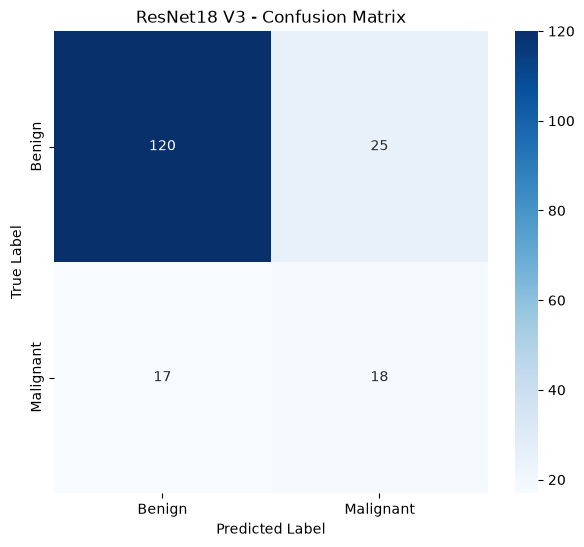


Classification Report:
              precision    recall  f1-score   support

      Benign       0.88      0.83      0.85       145
   Malignant       0.42      0.51      0.46        35

    accuracy                           0.77       180
   macro avg       0.65      0.67      0.66       180
weighted avg       0.79      0.77      0.78       180



In [45]:
# ============================================================
# Cell 41: V3 Confusion Matrix
# ============================================================

cm_v3 = confusion_matrix(
    y_true_v3,
    y_pred_v3
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_v3,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("ResNet18 V3 - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

print("\nClassification Report:")

print(
    classification_report(
        y_true_v3,
        y_pred_v3,
        target_names=[
            "Benign",
            "Malignant"
        ],
        zero_division=0
    )
)

In [46]:
# ============================================================
# Cell 42: Grad-CAM Setup
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load best V3 model
model_v3.load_state_dict(
    torch.load(
        V3_MODEL_PATH,
        map_location=device
    )
)

model_v3 = model_v3.to(device)
model_v3.eval()

print("V3 model loaded for Grad-CAM!")

V3 model loaded for Grad-CAM!


In [47]:
# ============================================================
# Cell 43: Grad-CAM
# ============================================================

class GradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        target_layer.register_forward_hook(
            self.save_activation
        )

        target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(
        self,
        module,
        input,
        output
    ):
        self.activations = output.detach()

    def save_gradient(
        self,
        module,
        grad_input,
        grad_output
    ):
        self.gradients = grad_output[0].detach()

    def generate(
        self,
        image_tensor,
        class_index
    ):

        self.model.zero_grad()

        output = self.model(
            image_tensor
        )

        score = output[:, class_index]

        score.backward()

        gradients = self.gradients
        activations = self.activations

        # Global average pooling
        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        # Weighted feature maps
        cam = (
            weights * activations
        ).sum(
            dim=1,
            keepdim=True
        )

        # ReLU
        cam = torch.relu(cam)

        # Remove batch/channel dimensions
        cam = cam.squeeze().cpu().numpy()

        # Normalize
        cam -= cam.min()

        if cam.max() != 0:
            cam /= cam.max()

        return cam


# ResNet18 final convolutional block
target_layer = model_v3.layer4[-1].conv2

gradcam = GradCAM(
    model_v3,
    target_layer
)

print("Grad-CAM ready!")

Grad-CAM ready!


In [48]:
# ============================================================
# Cell 44: Select Validation Image
# ============================================================

sample_index = 0

sample_row = val_df.iloc[sample_index]

image_path = sample_row["image_path"]
true_label = sample_row["label"]

print("Image:", image_path)
print("True label:", true_label)

Image: C:\Users\Vinay\OneDrive\Desktop\OncoVision AI\data\skin\ISBI2016_ISIC_Part3_Training_Data\ISIC_0010022.jpg
True label: benign


In [49]:
# ============================================================
# Cell 45: Generate Grad-CAM
# ============================================================

# Load original image
original_image = Image.open(
    image_path
).convert("RGB")

# Apply validation transformation
input_tensor = val_transforms_v3(
    original_image
).unsqueeze(0).to(device)

# Enable gradients
input_tensor.requires_grad_(True)

# Prediction
model_v3.eval()

output = model_v3(
    input_tensor
)

probabilities = torch.softmax(
    output,
    dim=1
)

predicted_class = torch.argmax(
    probabilities,
    dim=1
).item()

malignant_probability = probabilities[
    0, 1
].item()

class_names = [
    "Benign",
    "Malignant"
]

predicted_label = class_names[
    predicted_class
]

print("True label:", true_label)
print("Predicted:", predicted_label)
print(
    f"Malignant probability: "
    f"{malignant_probability:.4f}"
)

# Generate CAM
cam = gradcam.generate(
    input_tensor,
    predicted_class
)

print("Grad-CAM generated!")

True label: benign
Predicted: Benign
Malignant probability: 0.1766
Grad-CAM generated!


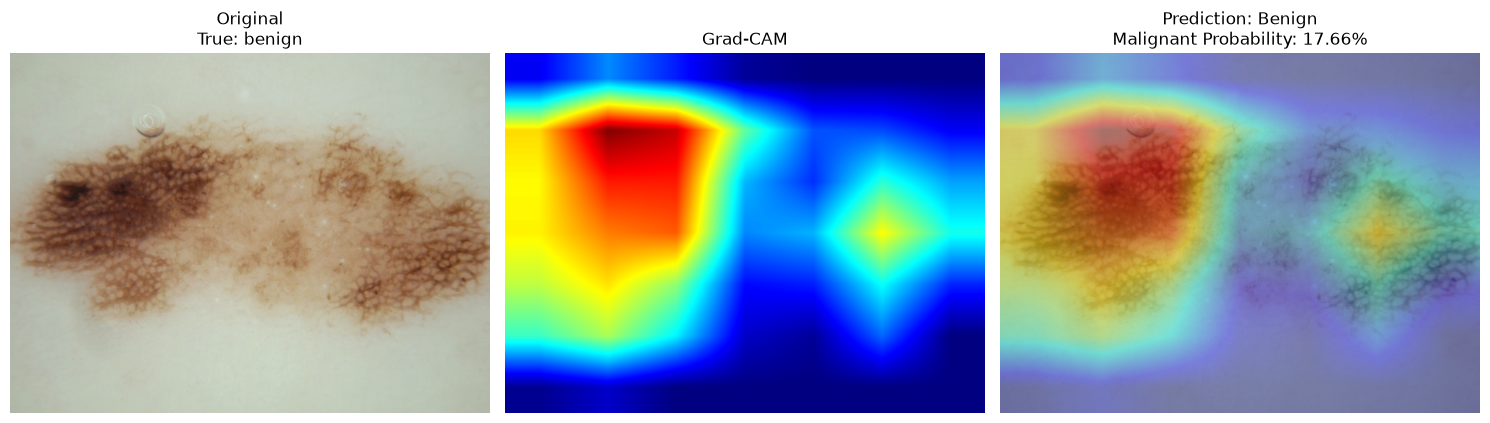

In [50]:
# ============================================================
# Cell 46: Display Grad-CAM
# ============================================================

original_np = np.array(
    original_image
)

# Resize CAM
cam_resized = cv2.resize(
    cam,
    (
        original_np.shape[1],
        original_np.shape[0]
    )
)

# Convert to heatmap
heatmap = np.uint8(
    255 * cam_resized
)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

heatmap = cv2.cvtColor(
    heatmap,
    cv2.COLOR_BGR2RGB
)

# Overlay
overlay = cv2.addWeighted(
    original_np,
    0.6,
    heatmap,
    0.4,
    0
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_np)
plt.title(
    f"Original\nTrue: {true_label}"
)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap)
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(
    f"Prediction: {predicted_label}\n"
    f"Malignant Probability: "
    f"{malignant_probability:.2%}"
)
plt.axis("off")

plt.tight_layout()
plt.show()